# Architecture of filters

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [2]:
import fitz

from utils import plot_pdf, symmetrical_cyclic_convolution

In [3]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

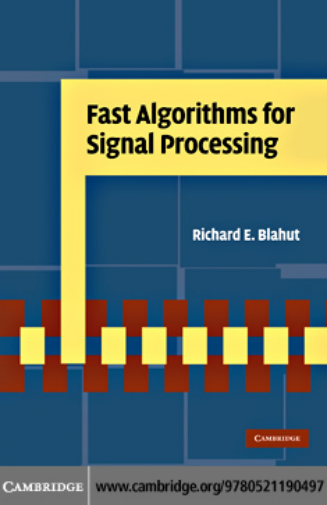

In [4]:
plot_pdf(doc[0], dpi=100)

## Polynomials

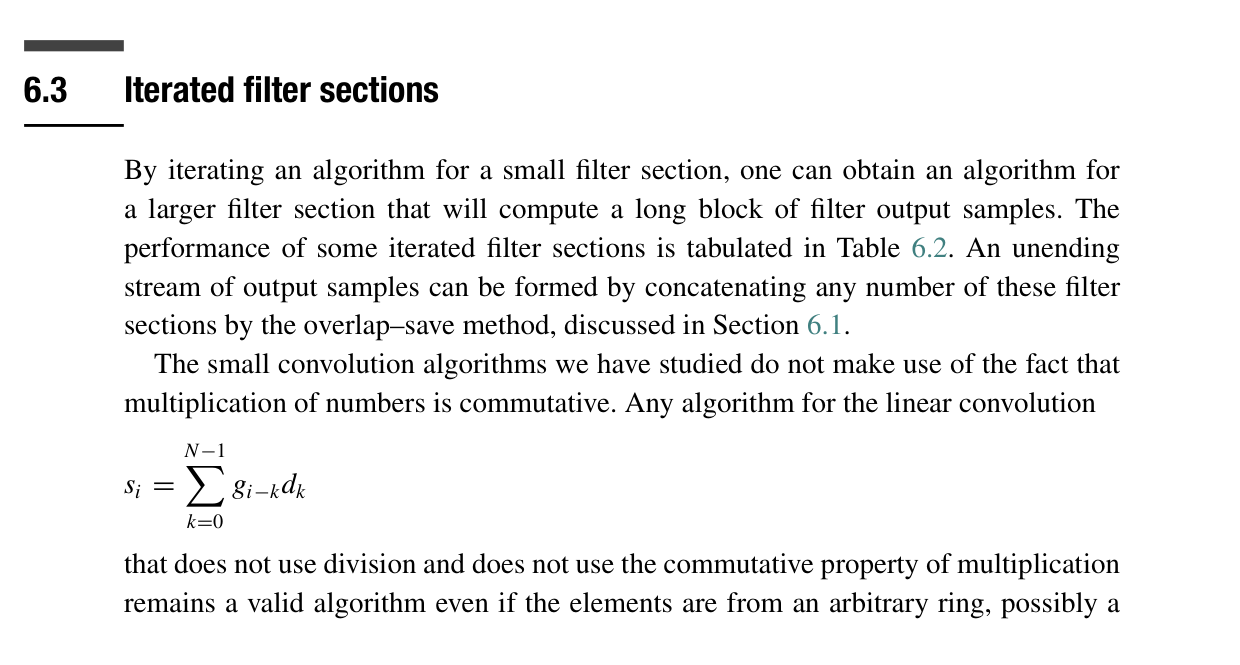

In [5]:
plot_pdf(doc[217], [.6, .95])

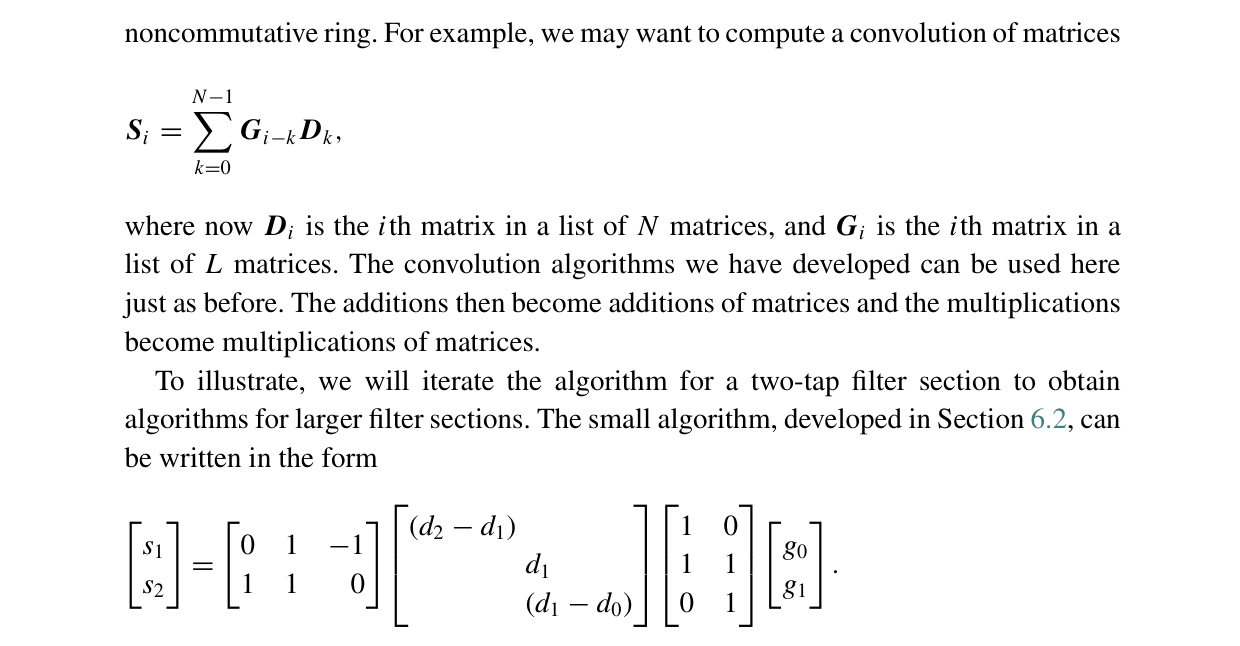

In [6]:
plot_pdf(doc[218], [.34, .68])

Size of vectors

In [187]:
d_num = 2
g_num = 2

Example of vectors for the convolution

In [188]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

In [189]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

1 1


In [190]:
x = sy.symbols("x")
x

x

In [191]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1]])

In [192]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1]])

In [193]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x

In [194]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x

In [195]:
sx = gx*dx
sx

(d_0 + d_1*x)*(g_0 + g_1*x)

Just defining values of matrices

In [197]:
a_mtx = sy.Matrix([[1, 1], [1, -1]])
a_mtx

Matrix([
[1,  1],
[1, -1]])

In [198]:
b_mtx = sy.Matrix([[1, 1], [1, -1]])
b_mtx

Matrix([
[1,  1],
[1, -1]])

In [199]:
c_mtx = sy.Matrix([[1, 1], [1, -1]])
c_mtx

Matrix([
[1,  1],
[1, -1]])

In [200]:
cd_mtx = sy.diag(*(b_mtx.T*gi).tolist())
cd_mtx

Matrix([
[g_0 + g_1,         0],
[        0, g_0 - g_1]])

In [201]:
bg_mtx = sy.diag(*(b_mtx*gi*1/2).tolist())
bg_mtx

Matrix([
[g_0/4 + g_1/4,             0],
[            0, g_0/4 - g_1/4]])

In [203]:
sy.Matrix(symmetrical_cyclic_convolution(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[d_0*g_0 + d_1*g_1],
[d_0*g_1 + d_1*g_0]])

In [22]:
#sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)

In [204]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
se

Matrix([
[1,  1],
[1, -1]])*Matrix([
[g_0/4 + g_1/4,             0],
[            0, g_0/4 - g_1/4]])*Matrix([
[1,  1],
[1, -1]])*Matrix([
[d_0],
[d_1]])

In [205]:
se = sy.MatMul(a_mtx.T * cd_mtx * a_mtx, gi)
se

Matrix([
[2*g_0, 2*g_1],
[2*g_1, 2*g_0]])*Matrix([
[g_0],
[g_1]])

In [206]:
sy.MatMul(a_mtx.T, cd_mtx, b_mtx, sy.Matrix(gi), evaluate=True)

Matrix([
[2*g_0**2 + 2*g_1**2],
[          4*g_0*g_1]])

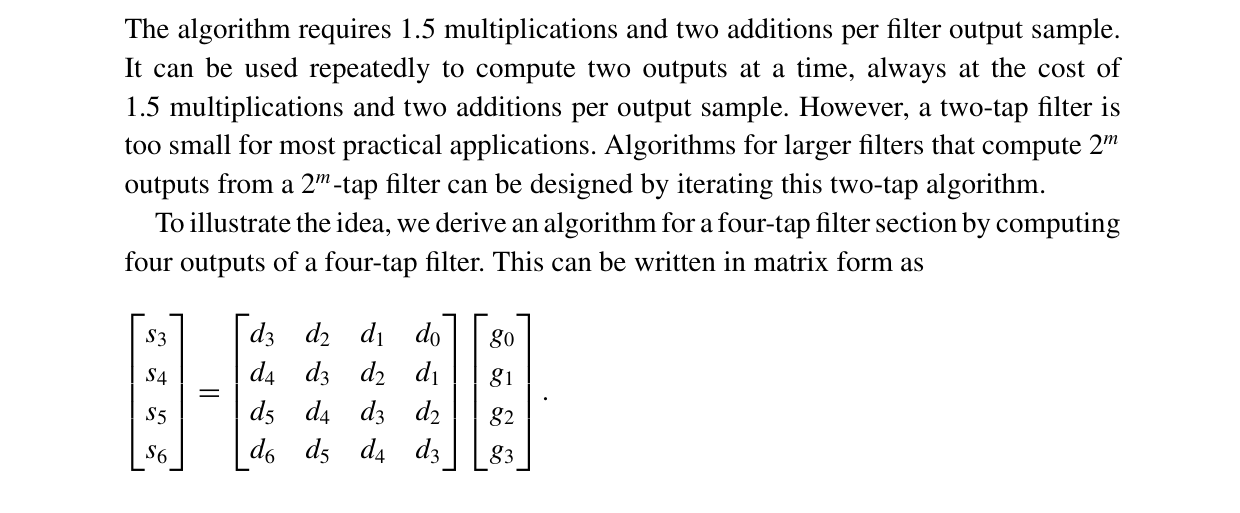

In [26]:
plot_pdf(doc[218], [.68, .95])

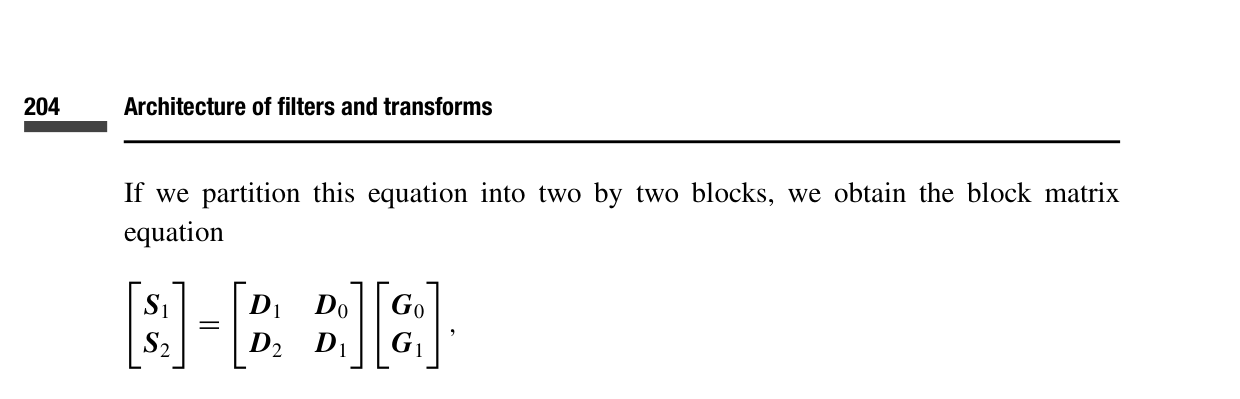

In [27]:
plot_pdf(doc[219], [0, .21])

In [28]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num*2+1))))
di

Matrix([
[d_0],
[d_1],
[d_2],
[d_3],
[d_4],
[d_5],
[d_6]])

In [29]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num*2))))
gi

Matrix([
[g_0],
[g_1],
[g_2],
[g_3]])

In [30]:
si = sy.Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(4))))
si

Matrix([
[s_0],
[s_1],
[s_2],
[s_3]])

In [31]:
ddi = sy.Matrix(sy.symbols(" ".join(f"D_{i}"for i in range(4))))
ddi

Matrix([
[D_0],
[D_1],
[D_2],
[D_3]])

In [32]:
ggi = sy.Matrix(sy.symbols(" ".join(f"G_{i}"for i in range(2))))
ggi

Matrix([
[G_0],
[G_1]])

In [33]:
ssi = sy.Matrix(sy.symbols(" ".join(f"S_{i}"for i in range(3))))
ssi

Matrix([
[S_0],
[S_1],
[S_2]])

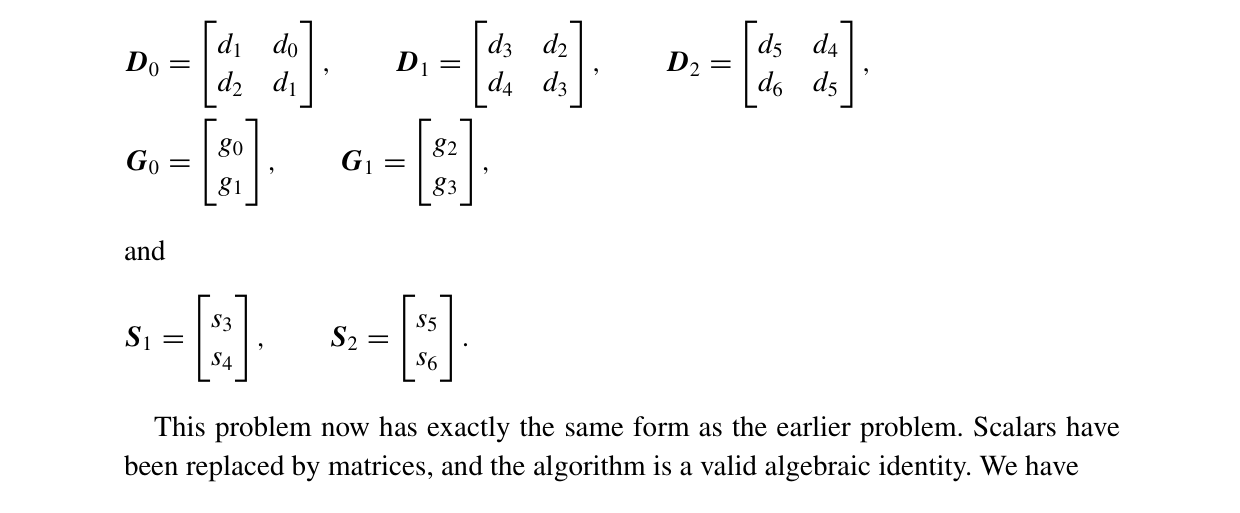

In [34]:
plot_pdf(doc[219], [.23, .5])

In [94]:
dd = [None for n in range(4)]

In [95]:
dd[0] = sy.Matrix(
    [
    [di[1], di[0]],
    [di[2], di[1]]
    ]
)
dd[0]

Matrix([
[d_1, d_0],
[d_2, d_1]])

In [96]:
dd[1] = sy.Matrix(
    [
    [di[3], di[2]],
    [di[4], di[3]]
    ]
)
dd[1]

Matrix([
[d_3, d_2],
[d_4, d_3]])

In [97]:
dd[2] = sy.Matrix(
    [
    [di[5], di[4]],
    [di[6], di[5]]
    ]
)
dd[2]

Matrix([
[d_5, d_4],
[d_6, d_5]])

In [98]:
gg = [None for n in range(2)]
gg

[None, None]

In [99]:
gg[0] = sy.Matrix([gi[0], gi[1]])
gg[0]

Matrix([
[g_0],
[g_1]])

In [100]:
gg[1] = sy.Matrix([gi[2], gi[3]])
gg[1]

Matrix([
[g_2],
[g_3]])

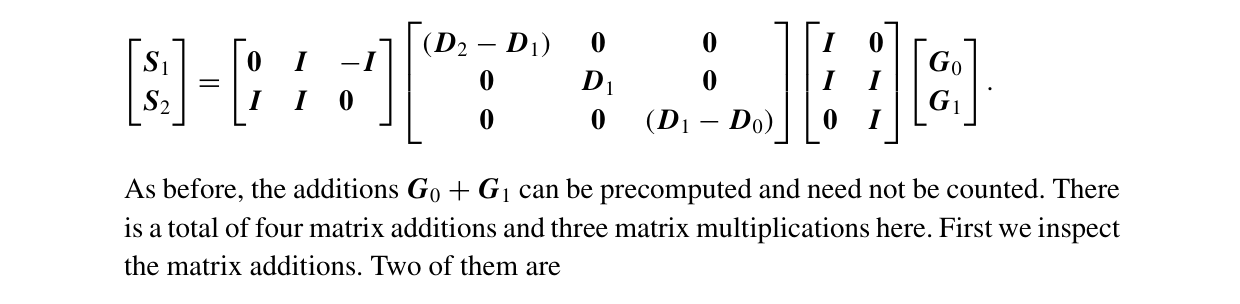

In [101]:
plot_pdf(doc[219], [.49, .65])

In [102]:
ii = sy.symbols('I')
ii

I

In [103]:
cc_mtx = sy.Matrix([
    [0, ii, -ii], 
    [ii, ii, 0]
])
cc_mtx

Matrix([
[0, I, -I],
[I, I,  0]])

In [104]:
gg_mtx = sy.Matrix([
    [ii, 0], 
    [ii, ii], 
    [0, ii]
])
gg_mtx

Matrix([
[I, 0],
[I, I],
[0, I]])

In [105]:
dd_mtx = sy.diag(*[
    ddi[2]  -ddi[1], 
    ddi[1], 
    ddi[1]-ddi[0]
])
dd_mtx

Matrix([
[-D_1 + D_2,   0,          0],
[         0, D_1,          0],
[         0,   0, -D_0 + D_1]])

In [106]:
gg_mtx

Matrix([
[I, 0],
[I, I],
[0, I]])

In [107]:
sy.MatMul(cc_mtx, dd_mtx, gg_mtx, ggi)

Matrix([
[0, I, -I],
[I, I,  0]])*Matrix([
[-D_1 + D_2,   0,          0],
[         0, D_1,          0],
[         0,   0, -D_0 + D_1]])*Matrix([
[I, 0],
[I, I],
[0, I]])*Matrix([
[G_0],
[G_1]])

In [108]:
ssx = sy.MatMul(cc_mtx, dd_mtx, gg_mtx, ggi, evaluate=True)
ssx

Matrix([
[D_1*G_0*I**2 + G_1*(D_1*I**2 - I**2*(-D_0 + D_1))],
[D_1*G_1*I**2 + G_0*(D_1*I**2 + I**2*(-D_1 + D_2))]])

In [112]:
cc_mtx = sy.Matrix([
    [sy.zeros(2,2), sy.eye(2), -sy.eye(2)], 
    [sy.eye(2), sy.eye(2), sy.zeros(2,2)]
])
cc_mtx

Matrix([
[0, 0, 1, 0, -1,  0],
[0, 0, 0, 1,  0, -1],
[1, 0, 1, 0,  0,  0],
[0, 1, 0, 1,  0,  0]])

In [113]:
gg_mtx = sy.Matrix([
    [sy.eye(2), sy.zeros(2,2)], 
    [sy.eye(2), sy.eye(2)], 
    [sy.zeros(2,2), sy.eye(2)]
])
gg_mtx

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[1, 0, 1, 0],
[0, 1, 0, 1],
[0, 0, 1, 0],
[0, 0, 0, 1]])

In [124]:
dd_mtx = sy.diag(*[
    dd[2]  -dd[1], 
    dd[1], 
    dd[1] - dd[0]
])
dd_mtx

Matrix([
[-d_3 + d_5, -d_2 + d_4,   0,   0,          0,          0],
[-d_4 + d_6, -d_3 + d_5,   0,   0,          0,          0],
[         0,          0, d_3, d_2,          0,          0],
[         0,          0, d_4, d_3,          0,          0],
[         0,          0,   0,   0, -d_1 + d_3, -d_0 + d_2],
[         0,          0,   0,   0, -d_2 + d_4, -d_1 + d_3]])

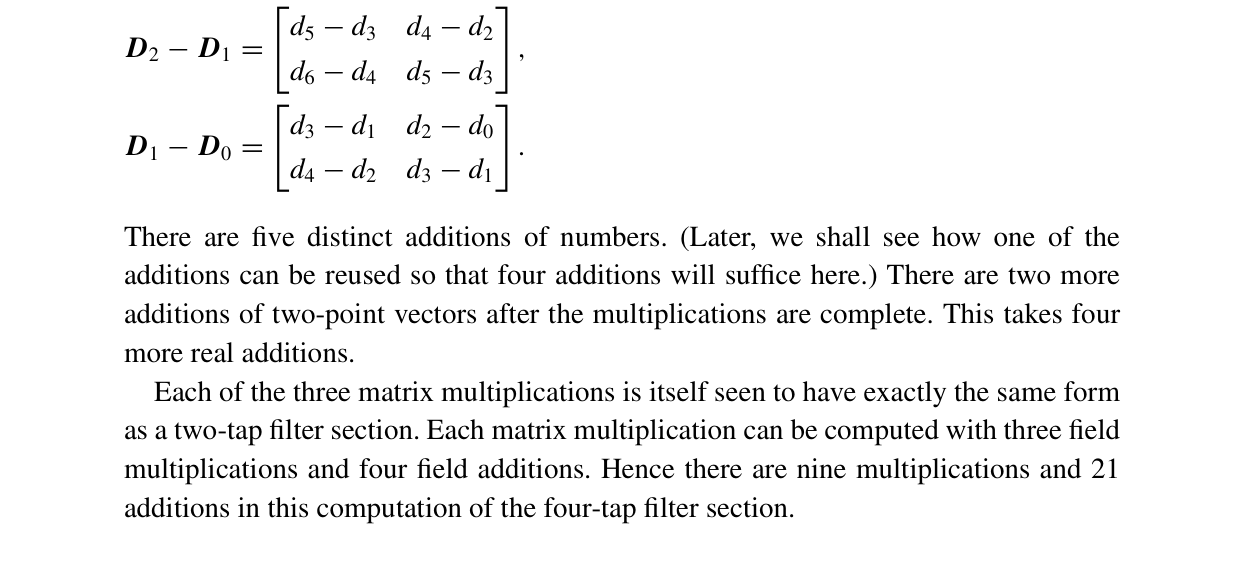

In [115]:
plot_pdf(doc[219], [.65, .95])

In [167]:
sy.Matrix(symmetrical_cyclic_convolution(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[d_0*g_0 + d_4*g_3 + d_5*g_2 + d_6*g_1],
[d_0*g_1 + d_1*g_0 + d_5*g_3 + d_6*g_2],
[d_0*g_2 + d_1*g_1 + d_2*g_0 + d_6*g_3],
[d_0*g_3 + d_1*g_2 + d_2*g_1 + d_3*g_0],
[d_1*g_3 + d_2*g_2 + d_3*g_1 + d_4*g_0],
[d_2*g_3 + d_3*g_2 + d_4*g_1 + d_5*g_0],
[d_3*g_3 + d_4*g_2 + d_5*g_1 + d_6*g_0]])

In [125]:
ssx = sy.MatMul(cc_mtx, dd_mtx, gg_mtx, gi, evaluate=True)
ssx

Matrix([
[d_0*g_3 + d_1*g_2 + d_2*g_1 + d_3*g_0],
[d_1*g_3 + d_2*g_2 + d_3*g_1 + d_4*g_0],
[d_2*g_3 + d_3*g_2 + d_4*g_1 + d_5*g_0],
[d_3*g_3 + d_4*g_2 + d_5*g_1 + d_6*g_0]])

In [82]:
subs = {k: v for k, v in zip(di.flat(), range(0, len(di.flat())))}
subs

{d_0: 0, d_1: 1, d_2: 2, d_3: 3, d_4: 4, d_5: 5, d_6: 6}

In [117]:
dd_mtx_subs = dd_mtx.subs(subs)
dd_mtx_subs

Matrix([
[2, 2, 0, 0, 0, 0],
[2, 2, 0, 0, 0, 0],
[0, 0, 3, 2, 0, 0],
[0, 0, 4, 3, 0, 0],
[0, 0, 0, 0, 2, 2],
[0, 0, 0, 0, 2, 2]])

In [168]:
sy.Matrix(symmetrical_cyclic_convolution(range(len(di.flat())), range(len(gi.flat()))))

Matrix([
[28],
[27],
[19],
[ 4],
[10],
[16],
[22]])

In [186]:
r = cc_mtx * dd_mtx_subs * gg_mtx * sy.Matrix([2, 3, 0, 1])
r.T

Matrix([[12, 18, 24, 30]])

In [183]:
r = cc_mtx * dd_mtx_subs * gg_mtx * sy.Matrix([0, 1, 2, 3])
r.T

Matrix([[4, 10, 16, 22]])

In [134]:
cc_mtx * dd_mtx * gg_mtx * sy.Matrix([gi[0], 0, 0, 0])

Matrix([
[d_3*g_0],
[d_4*g_0],
[d_5*g_0],
[d_6*g_0]])